In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
import networkx as nx
from scipy.integrate import odeint

import re
from pathlib import Path

In [2]:
plt.rcParams["font.family"] = "Arial"

In [3]:
### Load data from HPC simulations

# Read data from HPC simulation
base_folder = Path(r"C:/Users/ip2347/Desktop/[rev] Simulations_CUSP/abm_outputs_scaling_hpc_0415/abm_outputs_scaling") ### CUSP


final_state_files = list(base_folder.glob("final_state_all_sims_by_N-*.csv"))

print("Number of files found:", len(final_state_files))
print("First few files:")

for f in final_state_files[:5]:
    print(f.name)

dfs_final = []

for file in final_state_files:
    temp = pd.read_csv(file)

    match = re.search(r"by_N-(\d+)\.csv$", file.name)
    if match and "N" not in temp.columns:
        temp["N"] = int(match.group(1))

    dfs_final.append(temp)

df_final = pd.concat(dfs_final, ignore_index=True)
df_final = df_final.sort_values(["N", "simulation"]).reset_index(drop=True)

print("\nMerged final-state dataframe:")
print(df_final.head())
print(df_final.shape)

Number of files found: 51
First few files:
final_state_all_sims_by_N-10.csv
final_state_all_sims_by_N-100.csv
final_state_all_sims_by_N-1000.csv
final_state_all_sims_by_N-10000.csv
final_state_all_sims_by_N-100000.csv

Merged final-state dataframe:
    N  simulation  R_final  V_final  W_final  time_index   time
0  10           0      0.3      0.6      0.1         476  9.996
1  10           1      0.3      0.7      0.0         476  9.996
2  10           2      0.2      0.7      0.1         476  9.996
3  10           3      0.3      0.7      0.0         476  9.996
4  10           4      0.3      0.7      0.0         476  9.996
(1224, 7)


In [4]:
# Parameter data
param_files = list(base_folder.glob("agent_parameter_summary_by_N-*.csv"))

print("Number of parameter files found:", len(param_files))

dfs_param = []

for file in param_files:
    temp = pd.read_csv(file)

    match = re.search(r"by_N-(\d+)\.csv$", file.name)
    if match and "N" not in temp.columns:
        temp["N"] = int(match.group(1))

    dfs_param.append(temp)

df_param = pd.concat(dfs_param, ignore_index=True)
df_param = df_param.sort_values(["N", "parameter"]).reset_index(drop=True)

print("\nMerged parameter dataframe:")
print(df_param.head())
print(df_param.shape)

Number of parameter files found: 51

Merged parameter dataframe:
    N parameter  baseline_value   cv      mean        sd
0  10      beta            0.00  0.0  0.000000  0.000000
1  10         e            1.10  0.4  1.284769  0.591057
2  10     gamma            0.25  0.4  0.222218  0.087234
3  10     kappa            3.50  0.4  4.586269  2.481648
4  10     sigma            0.10  0.4  0.101889  0.045263
(306, 6)


### Plot

In [5]:
df = df_final[df_final["N"] >= 10**4].copy()

df["R"] = df["R_final"] * df["N"]
df["W"] = df["W_final"] * df["N"]
df["V"] = df["V_final"] * df["N"]

df_mean = (df.groupby("N", as_index=False)
      .agg(R = ("R", "mean"), W = ("W", "mean"), V = ("V", "mean")))

def estimate_scaling(x, y):
    mask = (x > 0) & (y > 0)
    logx = np.log10(x[mask])
    logy = np.log10(y[mask])
    slope, intercept, r_value, _, _ = linregress(logx, logy)
    return slope, intercept, r_value**2


beta_R, int_R, r2_R = estimate_scaling(df_mean["N"], df_mean["R"])
beta_W, int_W, r2_W = estimate_scaling(df_mean["N"], df_mean["W"])
beta_V, int_V, r2_V = estimate_scaling(df_mean["N"], df_mean["V"])

print("Scaling exponents:")
print(f"R ~ N^{beta_R:.3f}, R² = {r2_R:.3f}")
print(f"W ~ N^{beta_W:.3f}, R² = {r2_W:.3f}")
print(f"V ~ N^{beta_V:.3f}, R² = {r2_V:.3f}")

N_fit = df_mean["N"]
R_fit = 10**int_R * N_fit**beta_R
W_fit = 10**int_W * N_fit**beta_W
V_fit = 10**int_V * N_fit**beta_V

Scaling exponents:
R ~ N^1.073, R² = 1.000
W ~ N^1.080, R² = 1.000
V ~ N^0.888, R² = 1.000


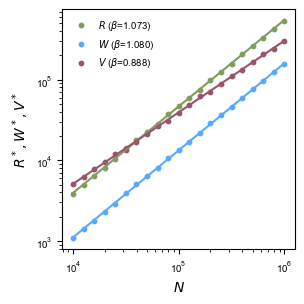

In [7]:
colors = ['#7f9e5d', '#56aaff', '#9b536d']

fig, ax = plt.subplots(figsize=(80/25.4, 80/25.4))

ax.scatter(df_mean["N"], df_mean["R"], color=colors[0], s = 10,  label = fr"$R$ ($\beta$={beta_R:.3f})")
ax.scatter(df_mean["N"], df_mean["W"], color=colors[1], s = 10, label = fr"$W$ ($\beta$={beta_W:.3f})")
ax.scatter(df_mean["N"], df_mean["V"], color=colors[2], s = 10, label = fr"$V$ ($\beta$={beta_V:.3f})")

ax.plot(N_fit, R_fit, color=colors[0])
ax.plot(N_fit, W_fit, color=colors[1])
ax.plot(N_fit, V_fit, color=colors[2])

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_ylabel(r"$R^*, W^*, V^*$", fontsize = 10)
ax.set_xlabel(r"$N$", fontsize = 10)
ax.tick_params(axis="both", labelsize = 7)
ax.tick_params(axis="both", labelsize = 7)

ax.legend(fontsize = 7, frameon = False)

plt.tight_layout()
#plt.savefig("C:/Users/ip2347/Desktop/[rev] Simulations_CUSP/[rev] Scaling_Sims_04_15_CV04.pdf", bbox_inches='tight', dpi = 900) ### CUSP
plt.show()